21
beep.wav


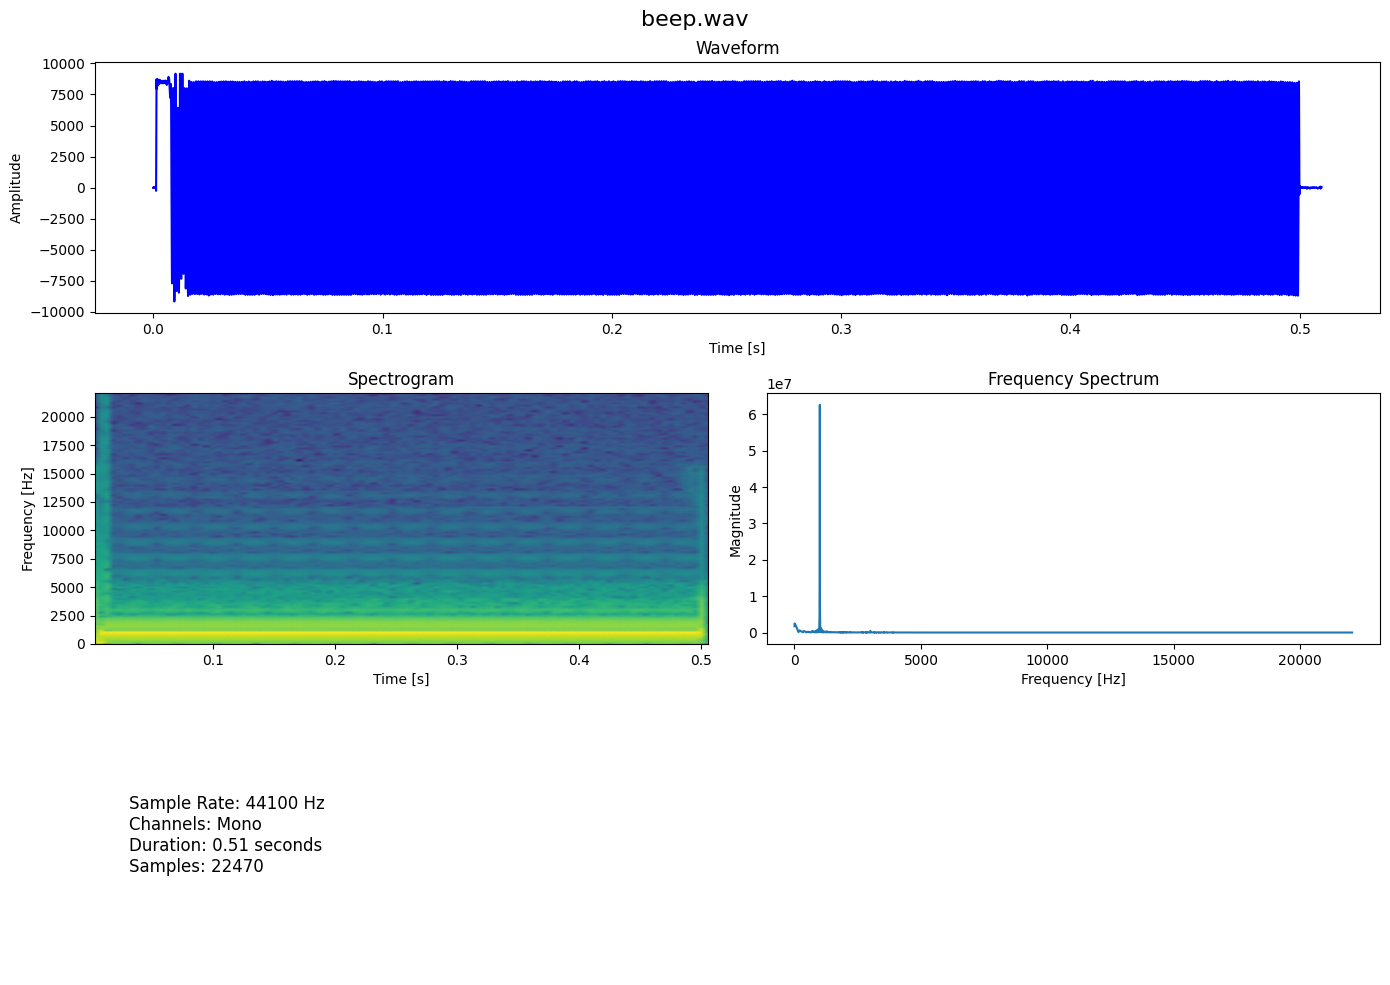

control_tone.wav


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_16696\3766763337.py:43: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')


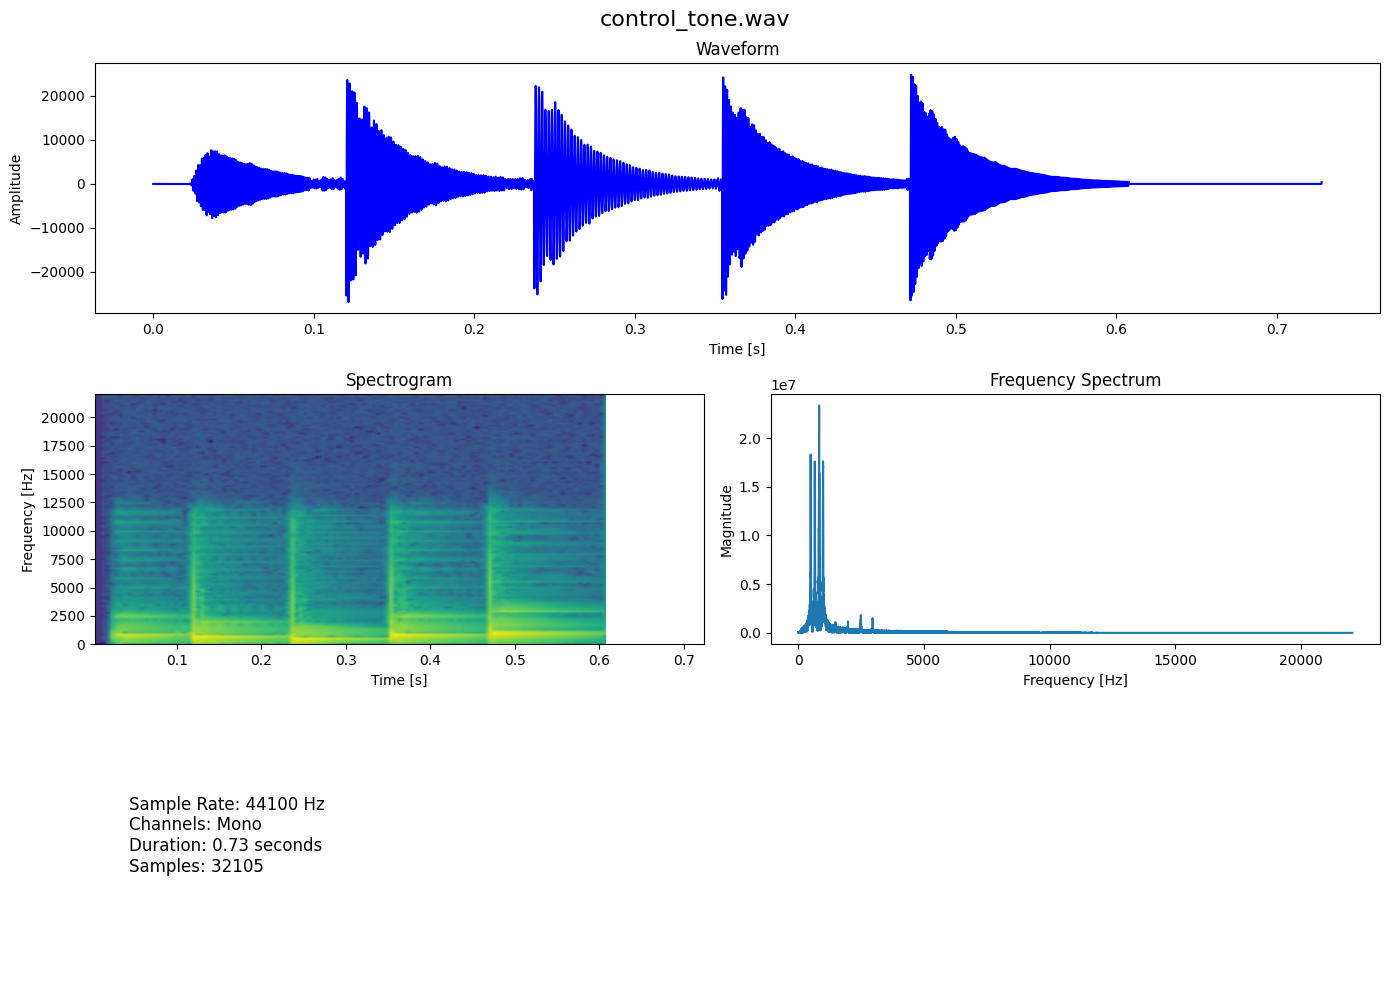

SD012_SD016_SD036_SD038_SD051_SD67_Whoop_doop.wav


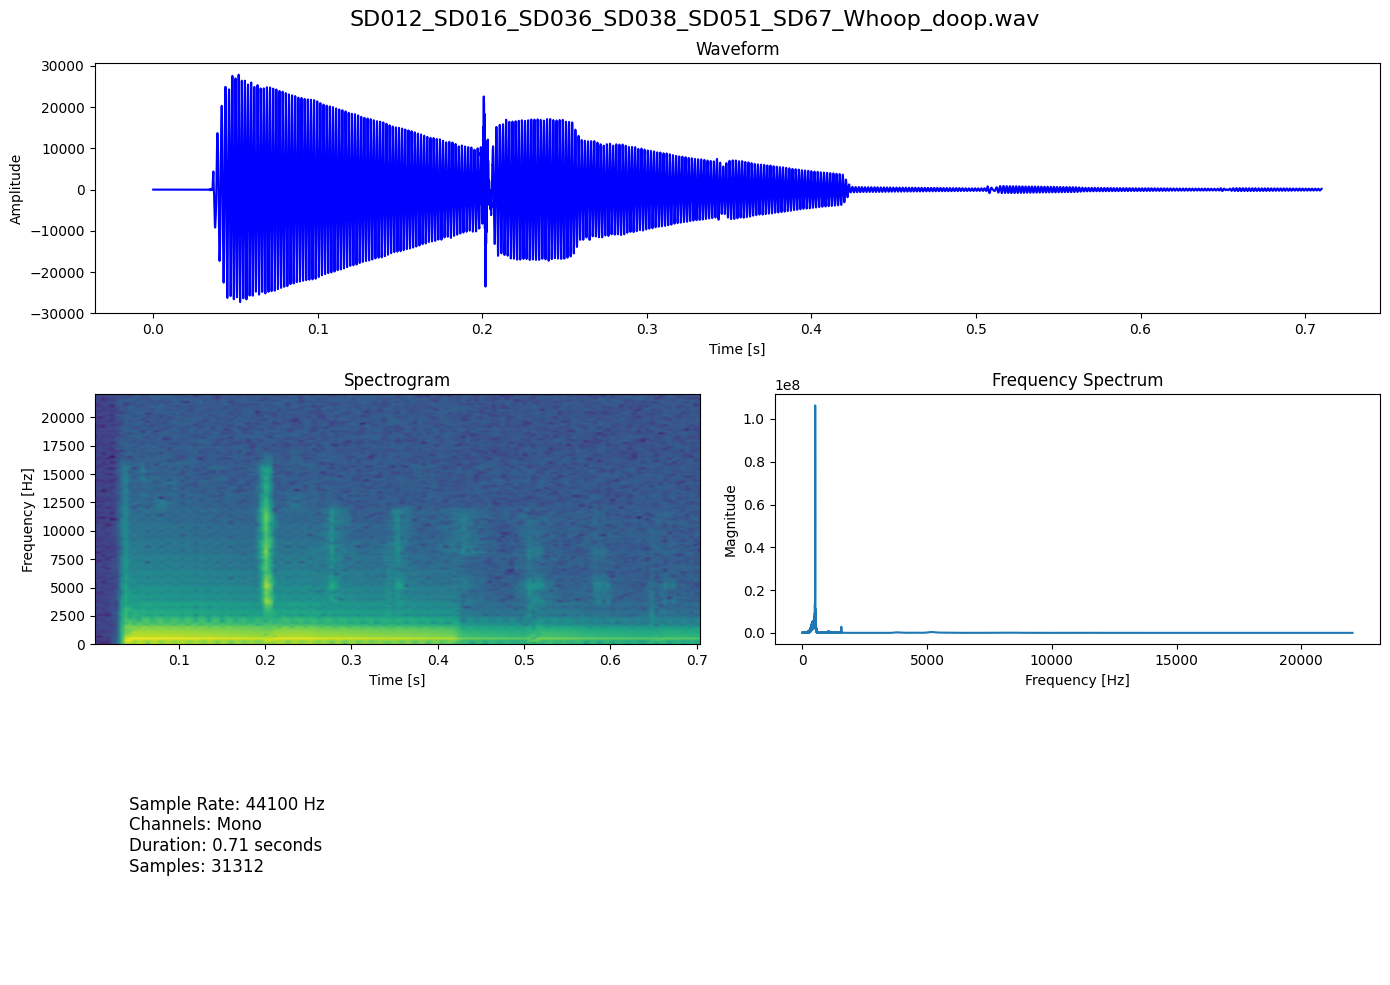

SD014_SD032_SD044_SD055_MI_droplets.wav


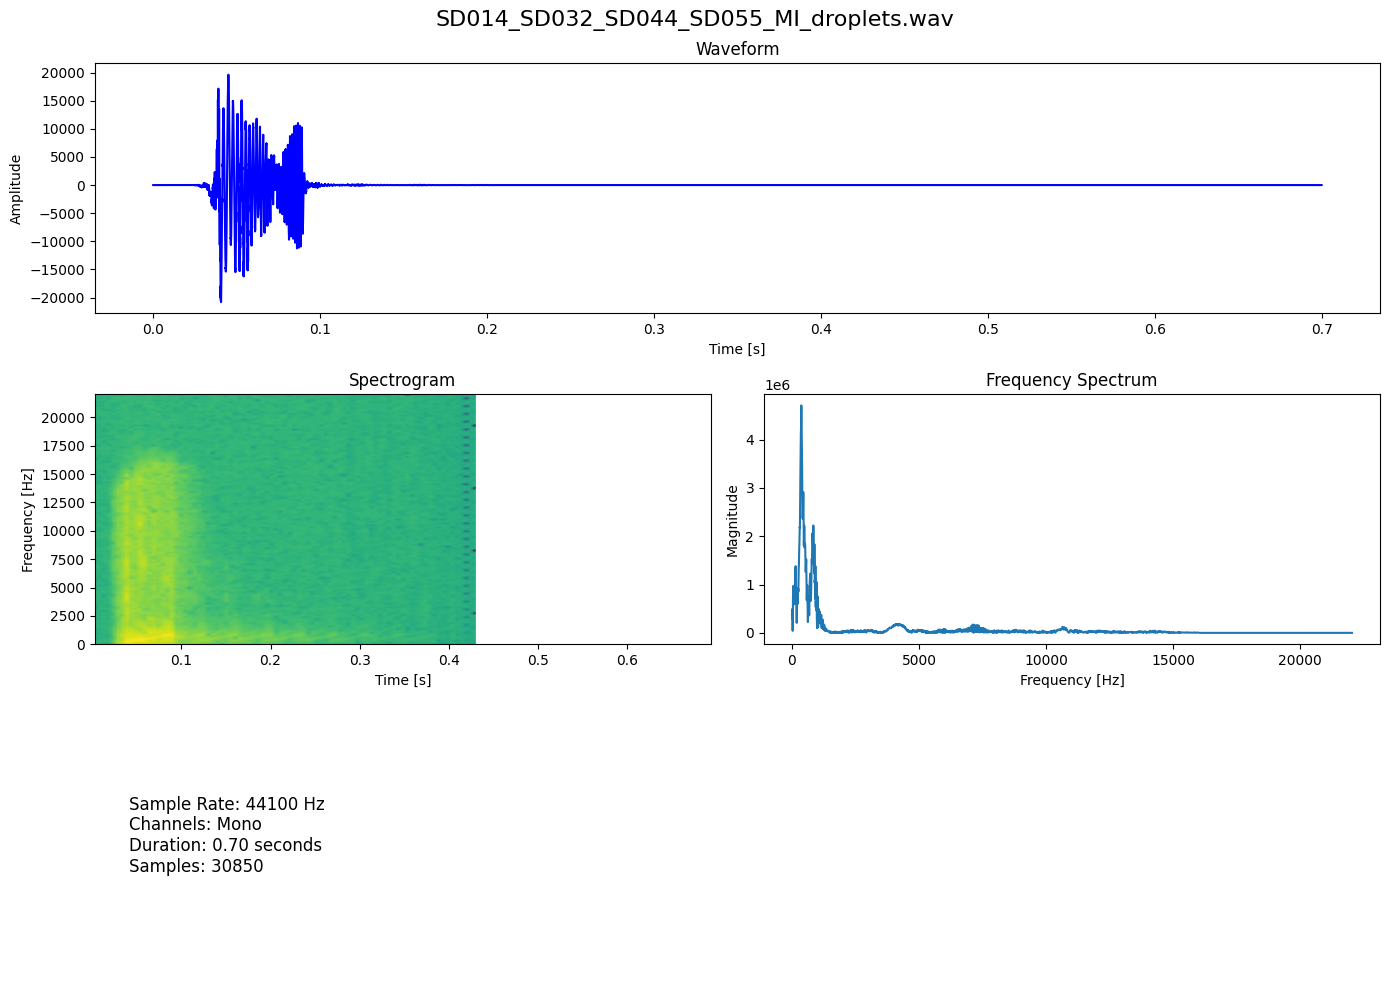

SD015_SD022_SD023_SD041_Realme_fun.wav


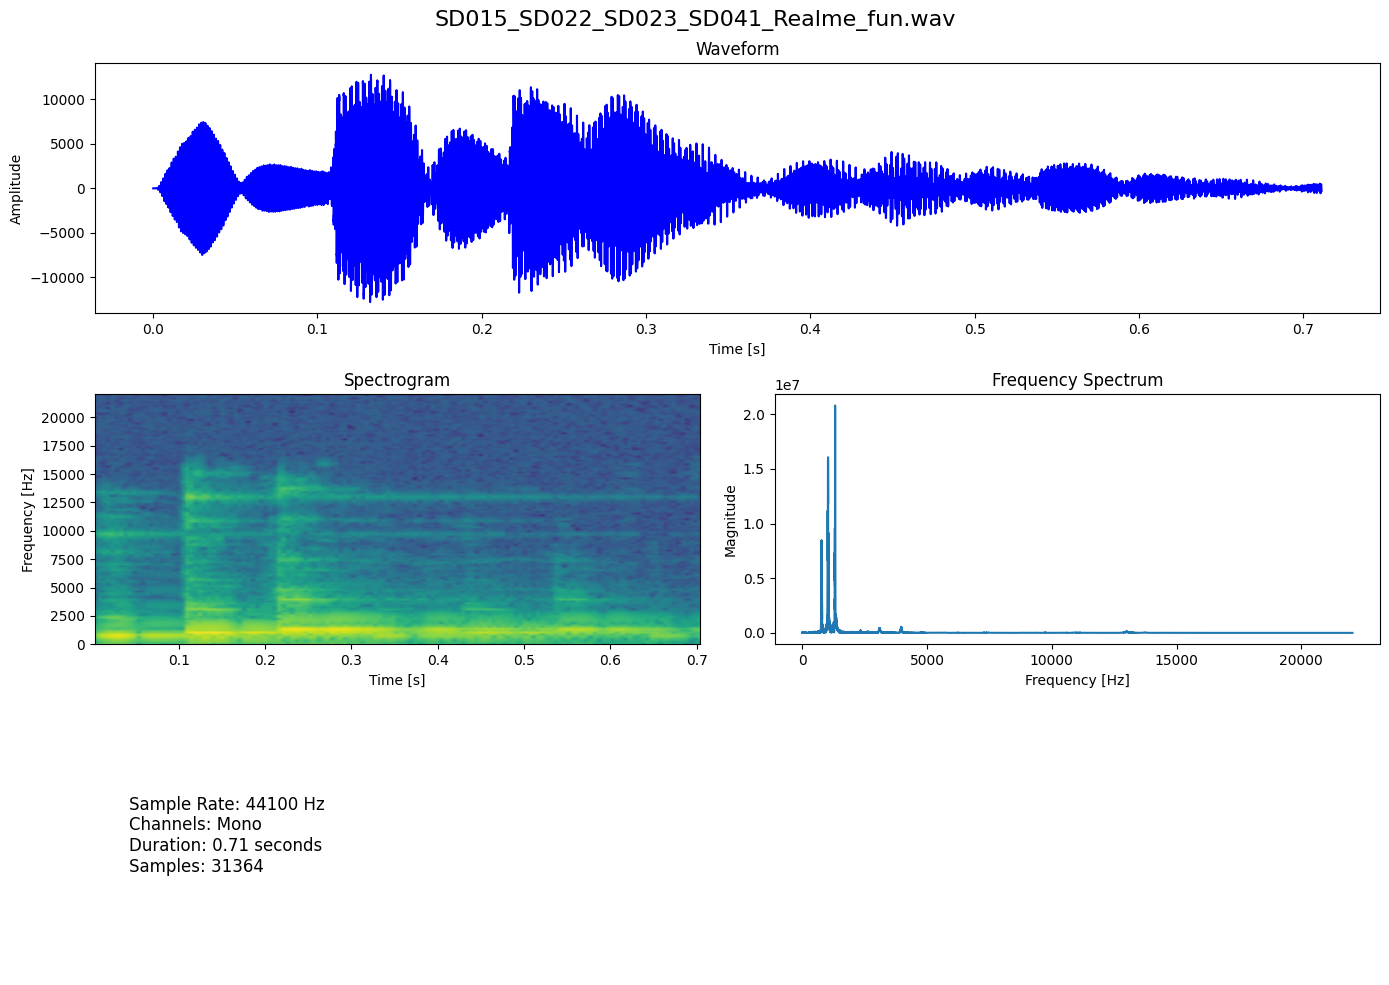

SD019_SD028_SD030_SD35_SD043_SD045_SD052_SD065_ipone_note.wav


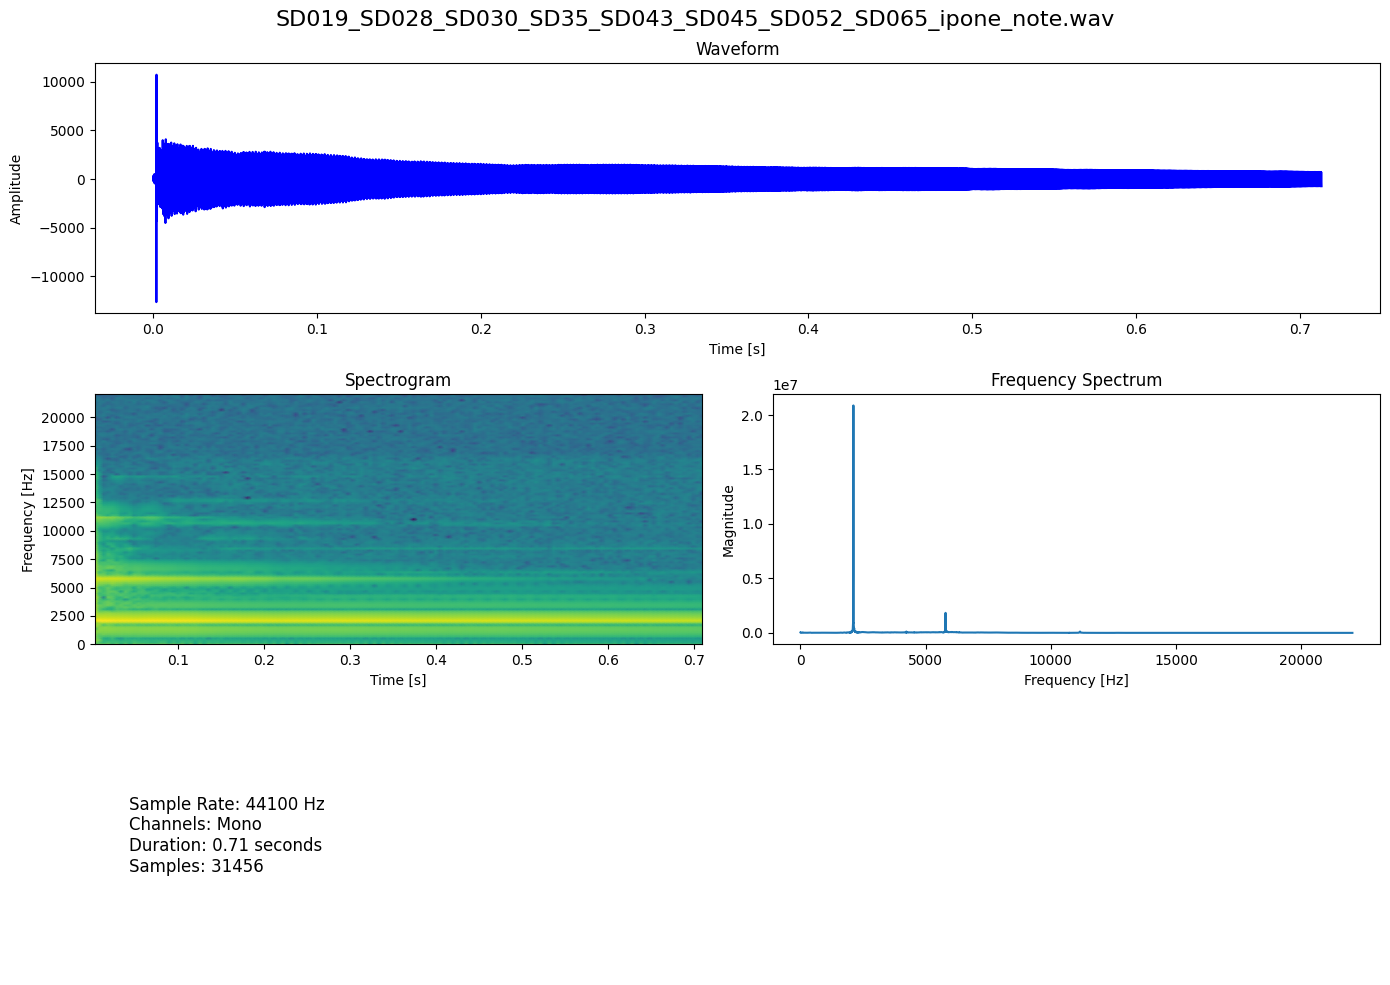

SD020_SD027_SD033_oneplustune.wav


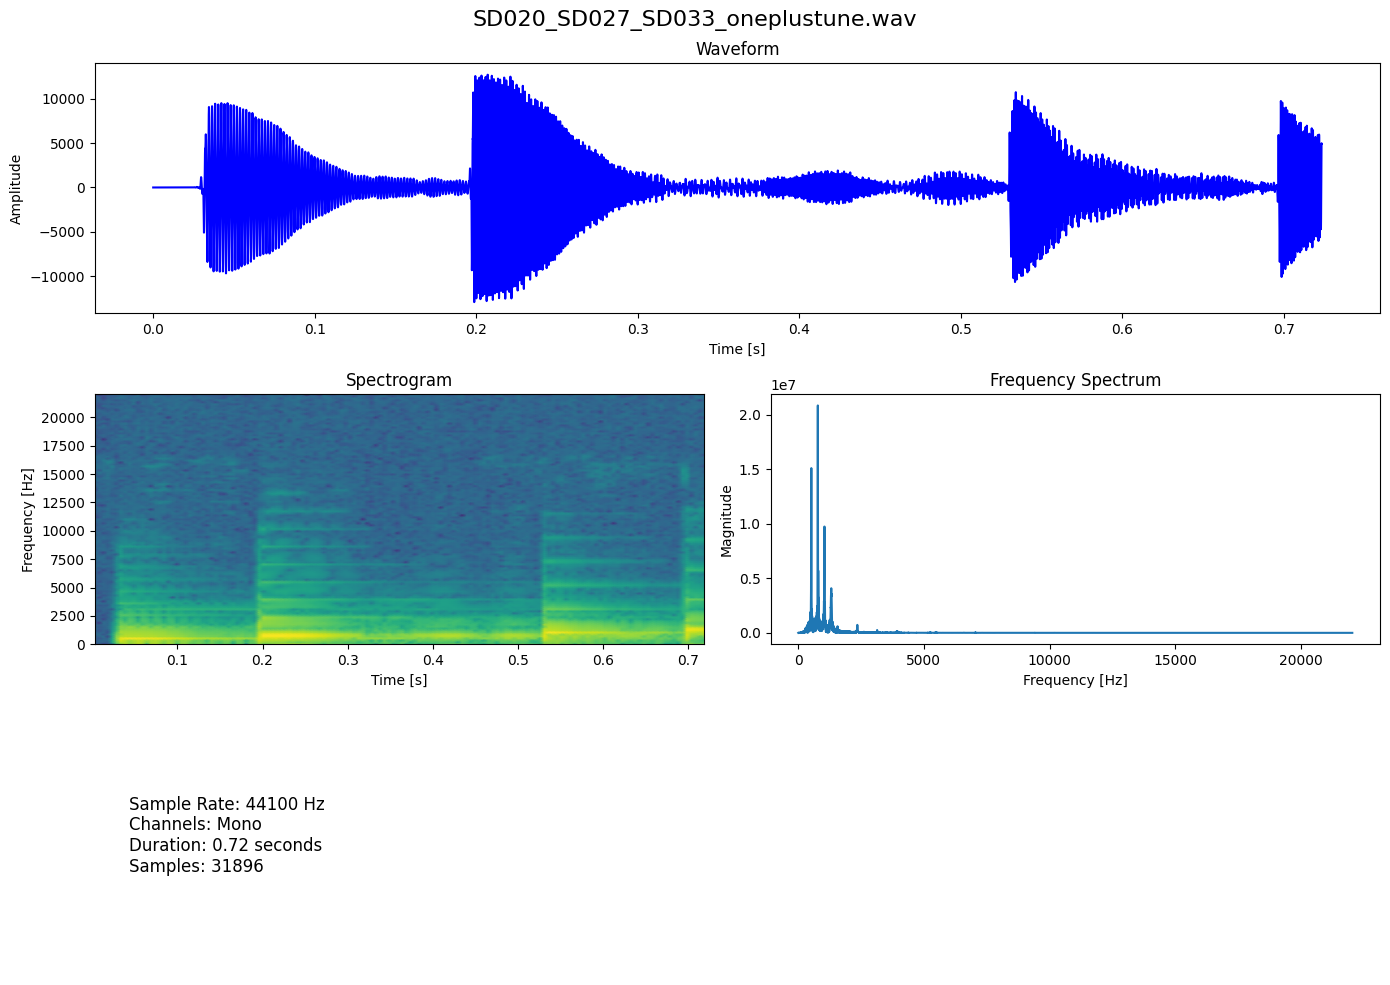

SD021_voyar.wav


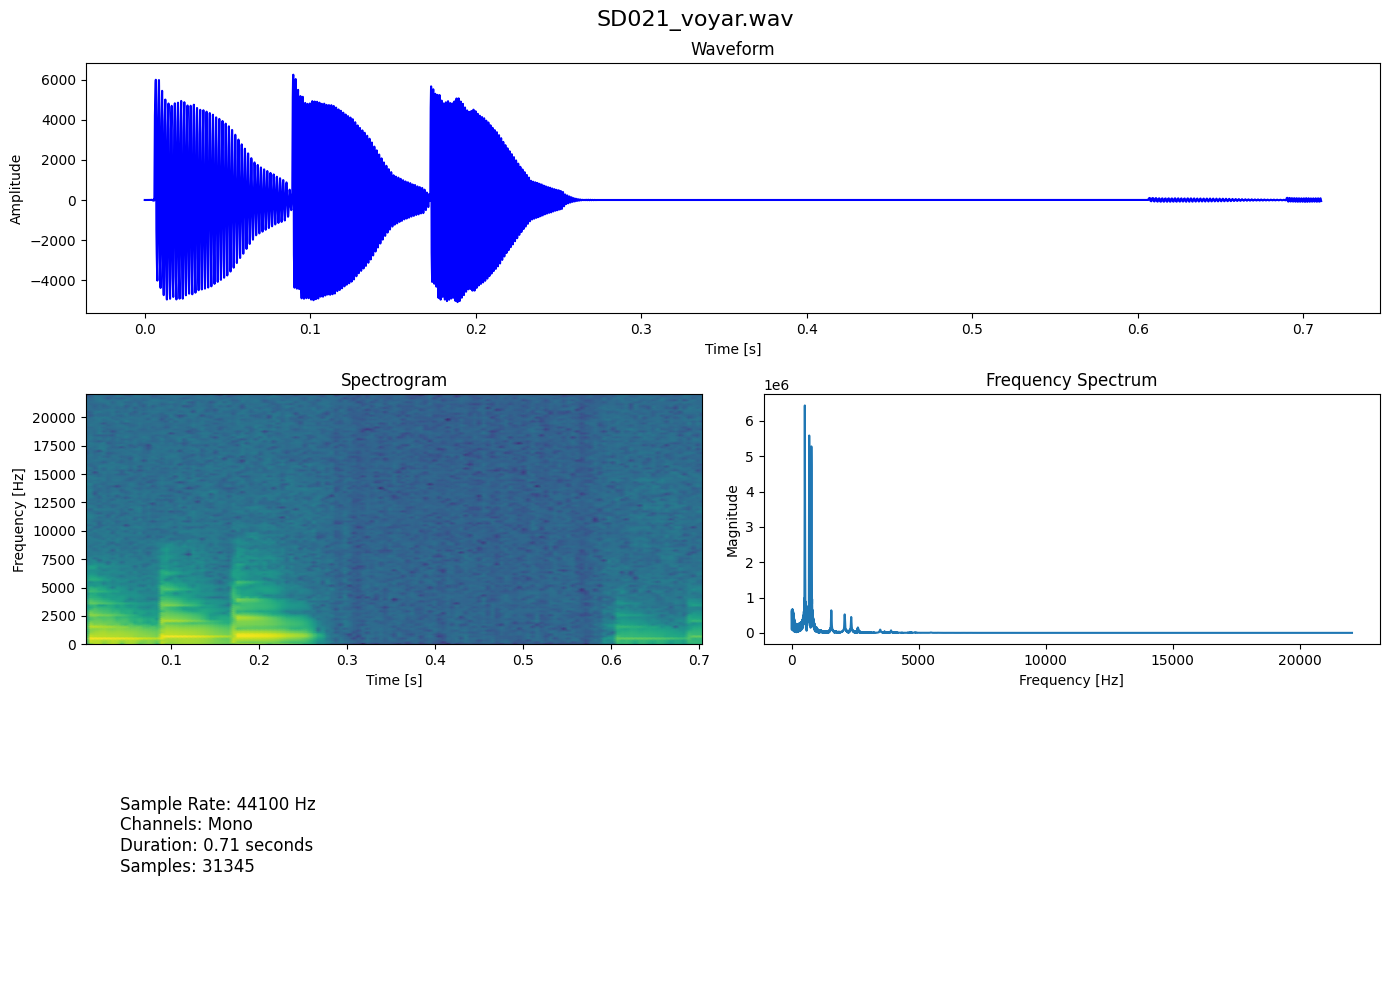

SD024_SD049_oneplus_meet.wav


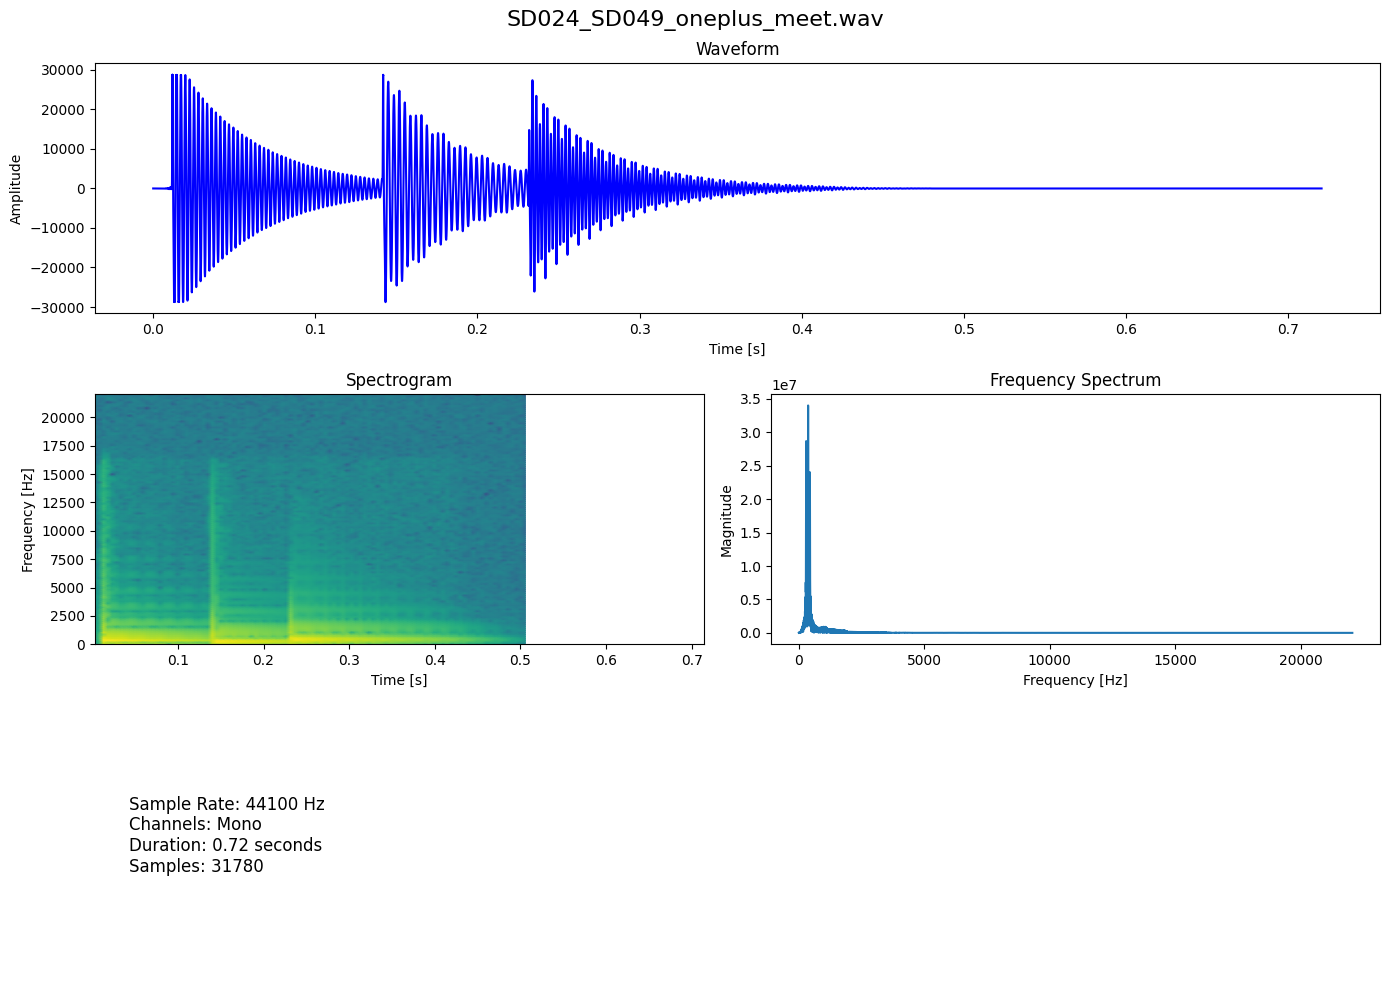

SD025_oneplus_blissful.wav


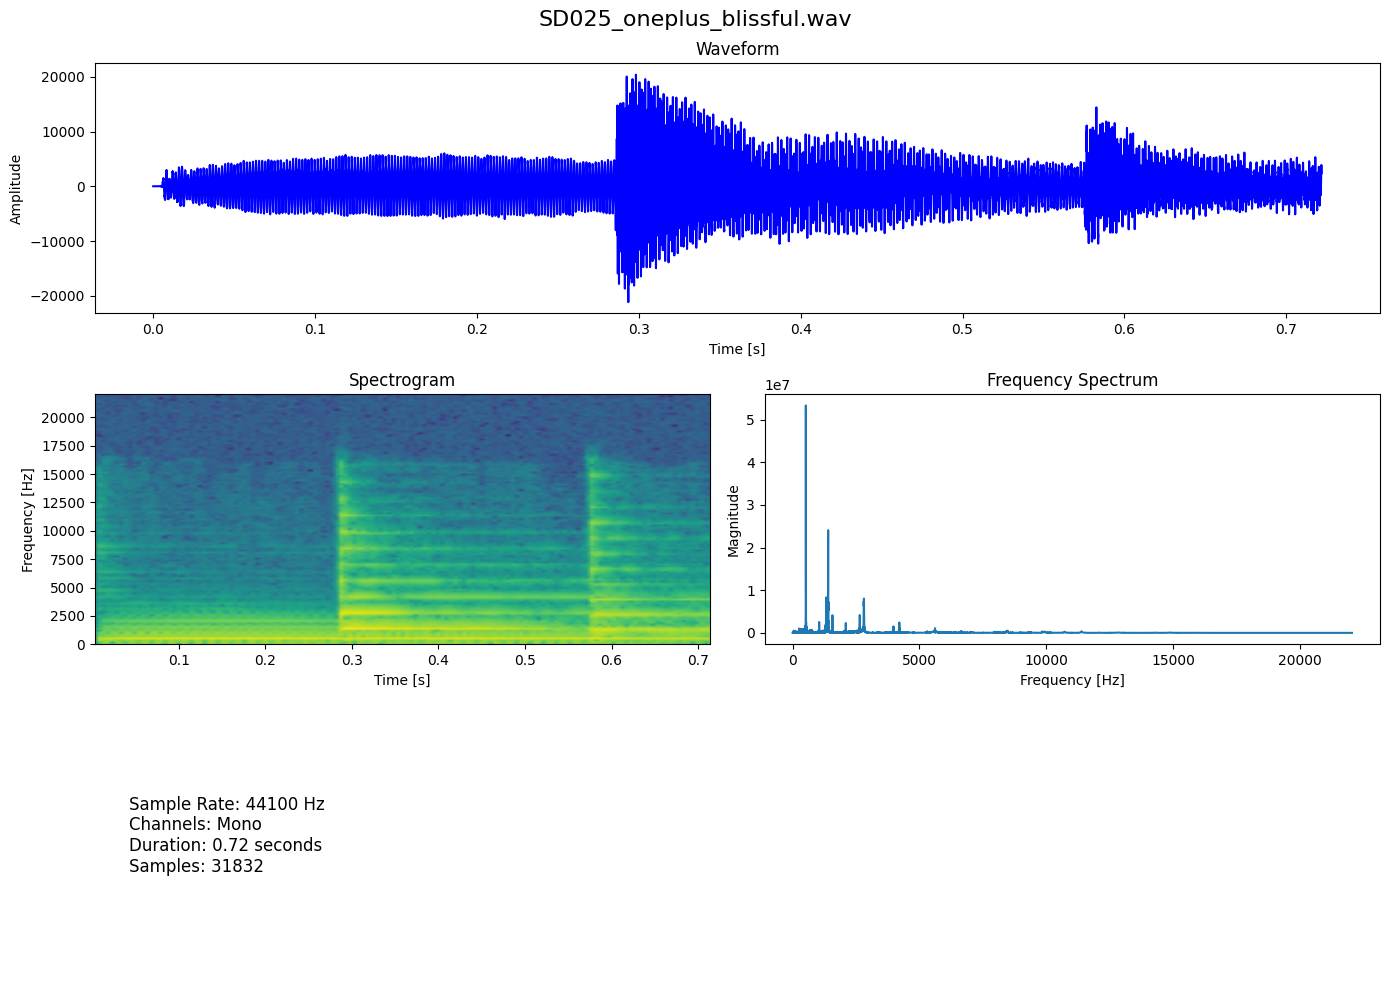

SD028_realme.wav


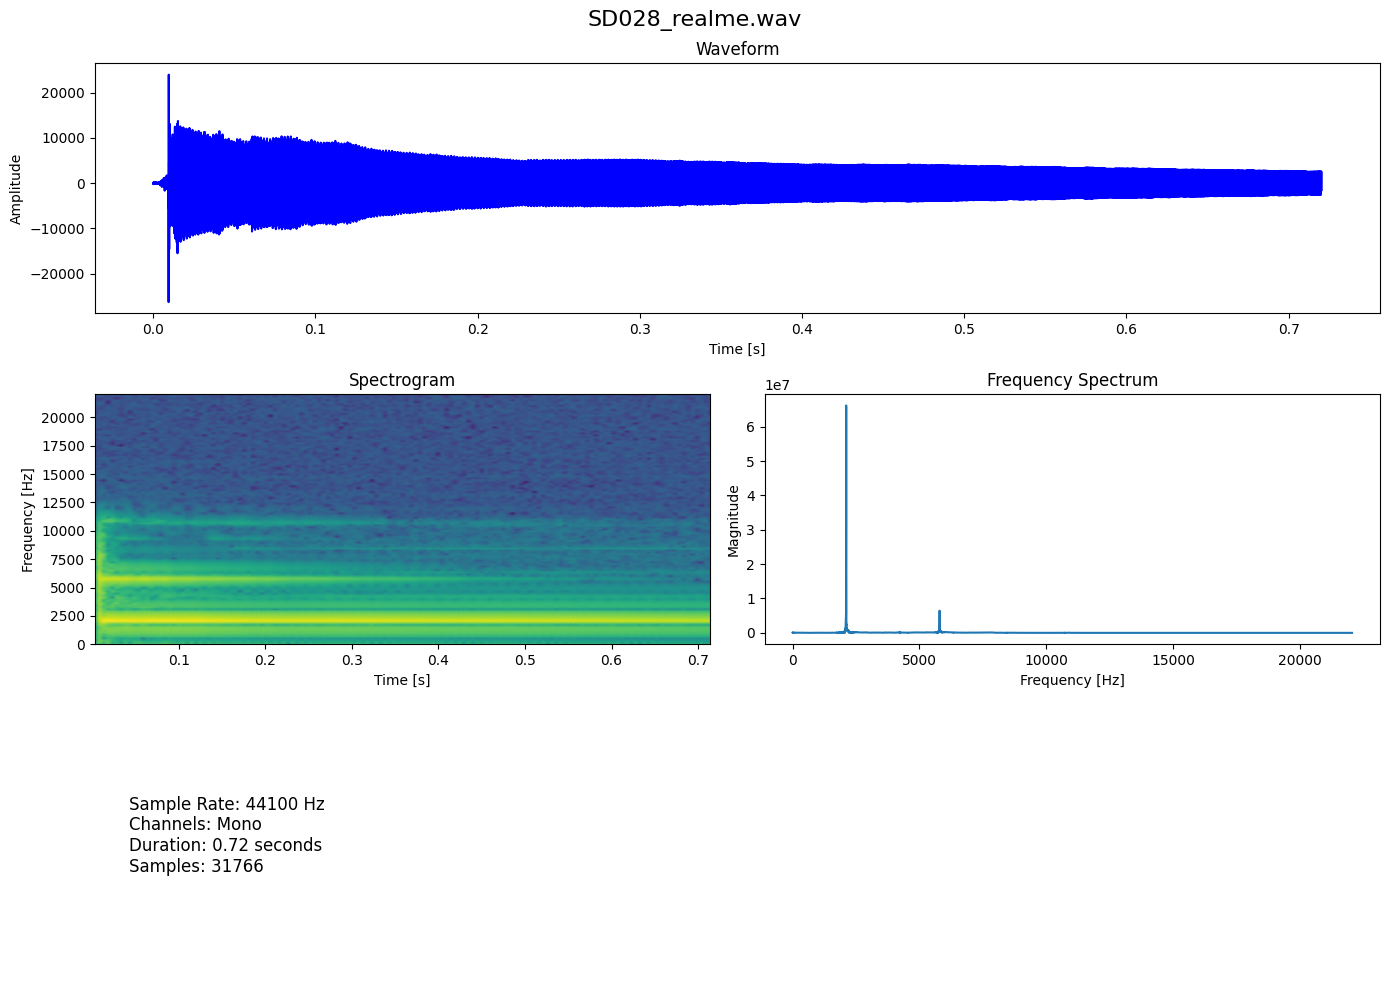

SD030_SD042_encounter_vivo.wav


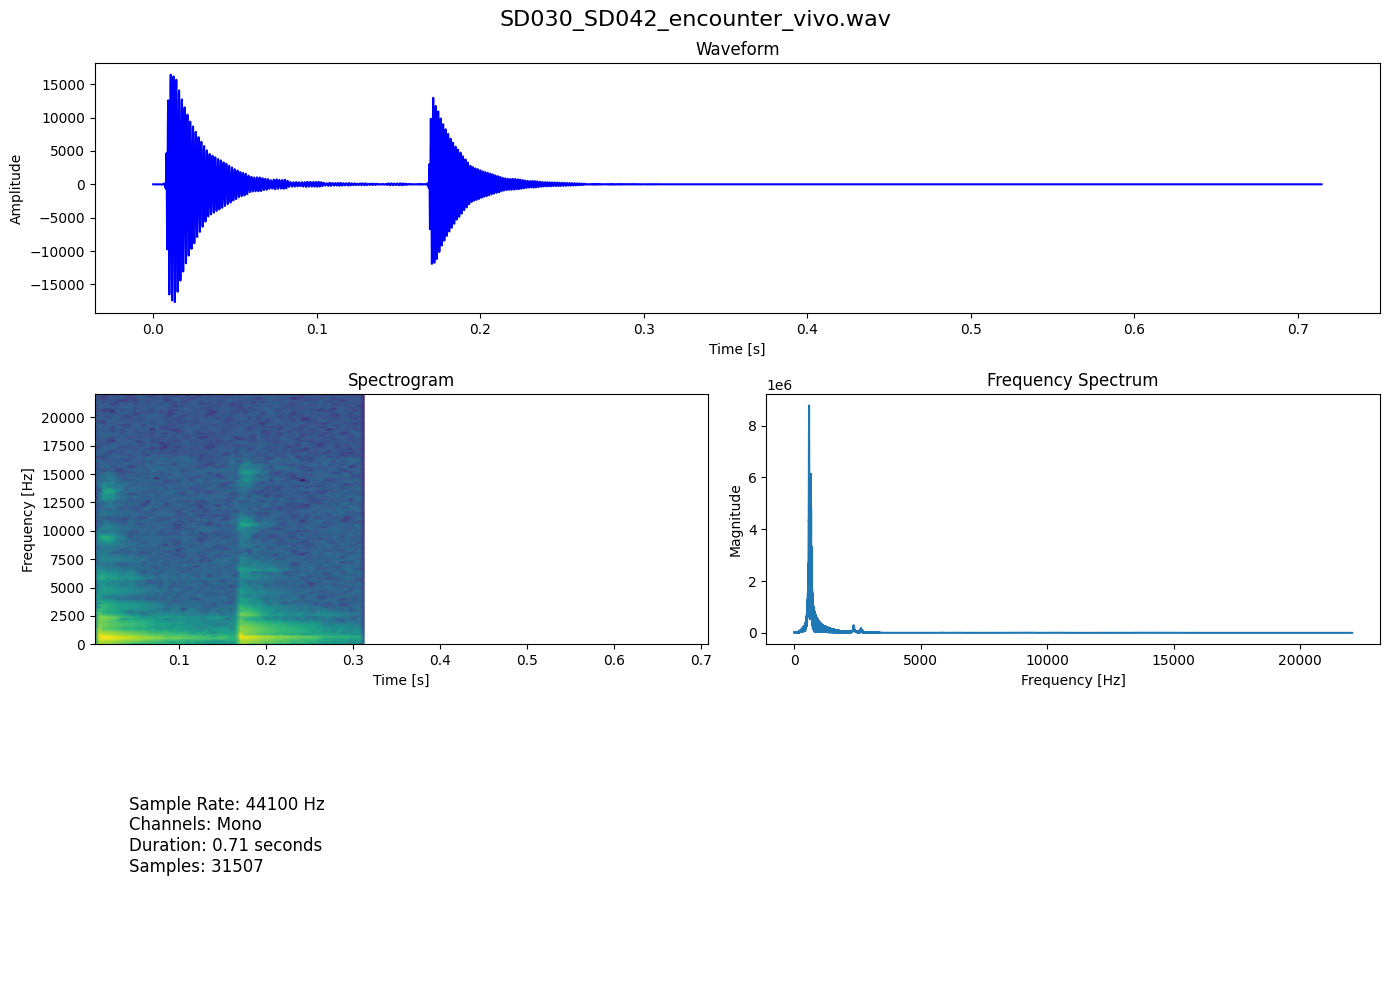

SD034_SD050_SD059_vibration.wav


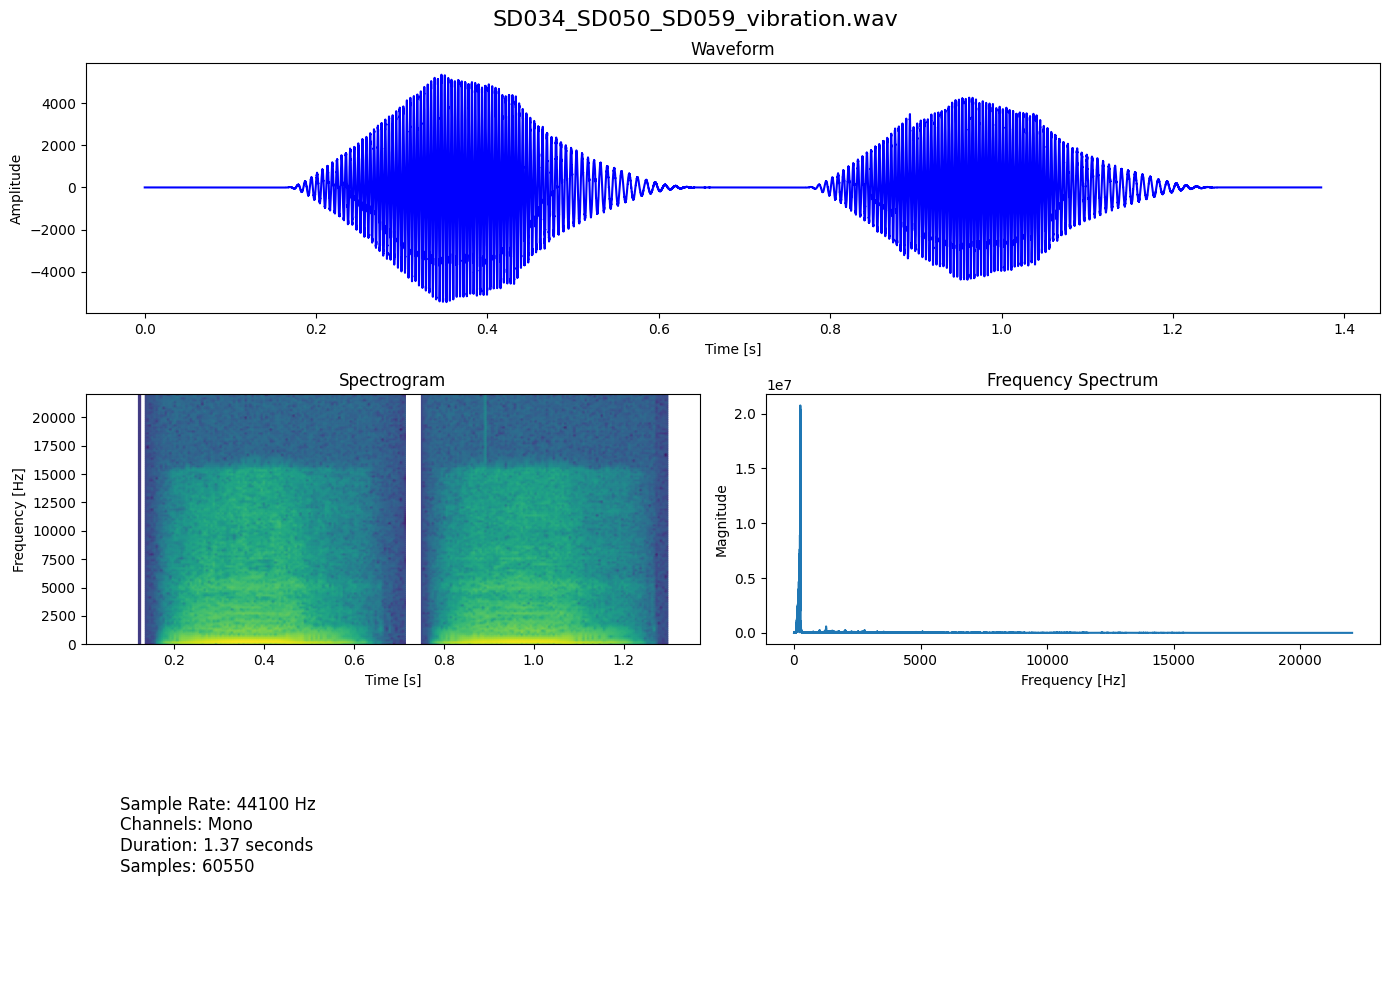

SD037_SD053_SD062_oppo.wav
SD037_SD053_SD062_oppo.wav  NO able  to read
SD039_SD040_oppo_joy.wav


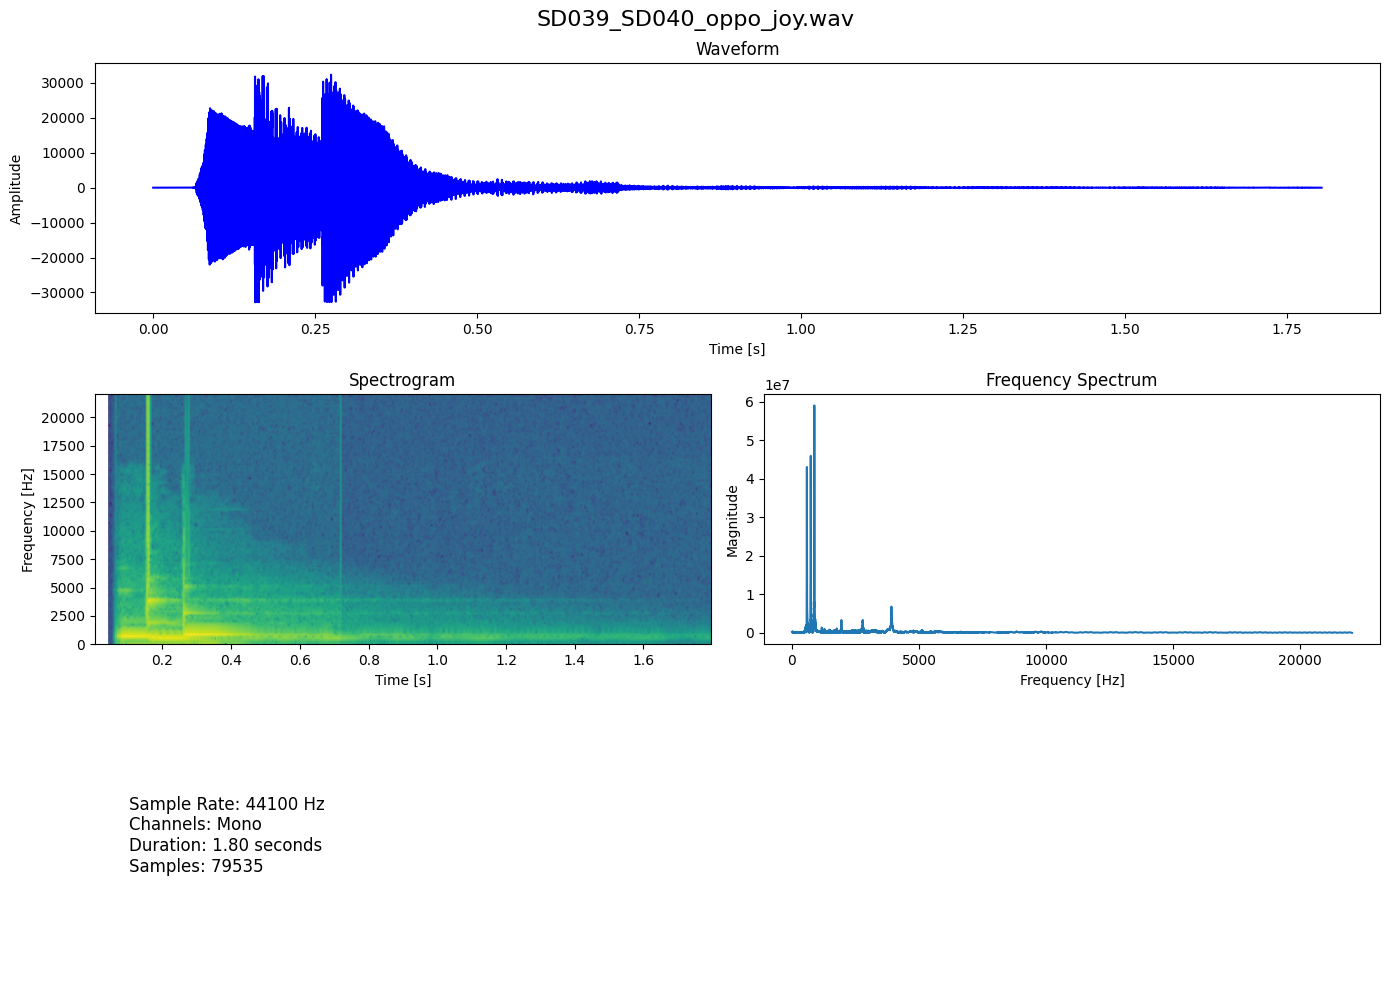

SD057_jai_shree_shyam.wav


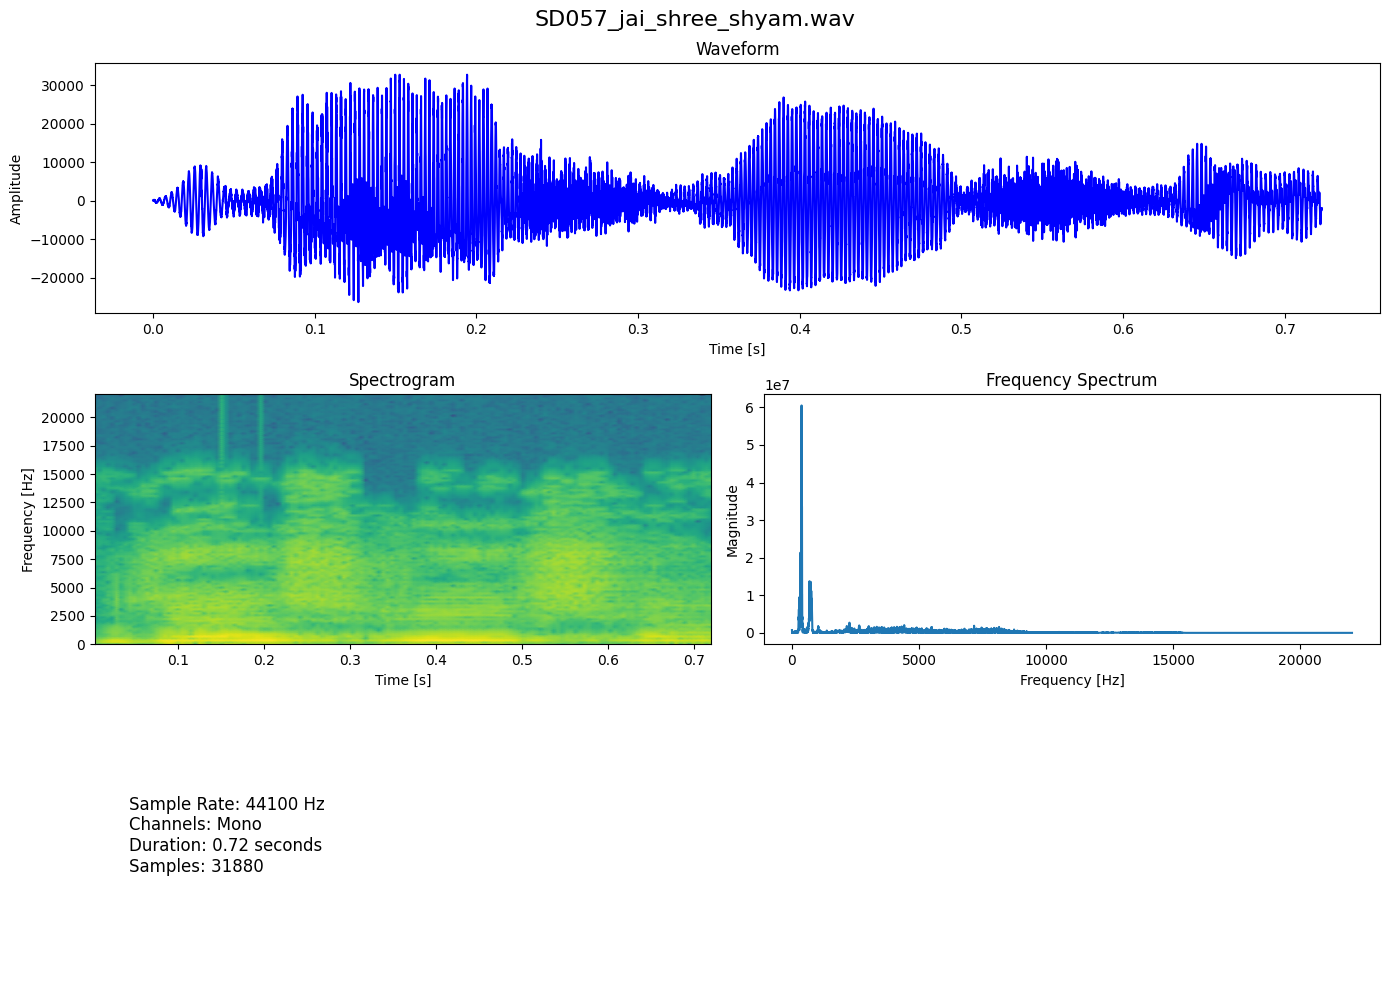

SD058_andes_vivo.wav


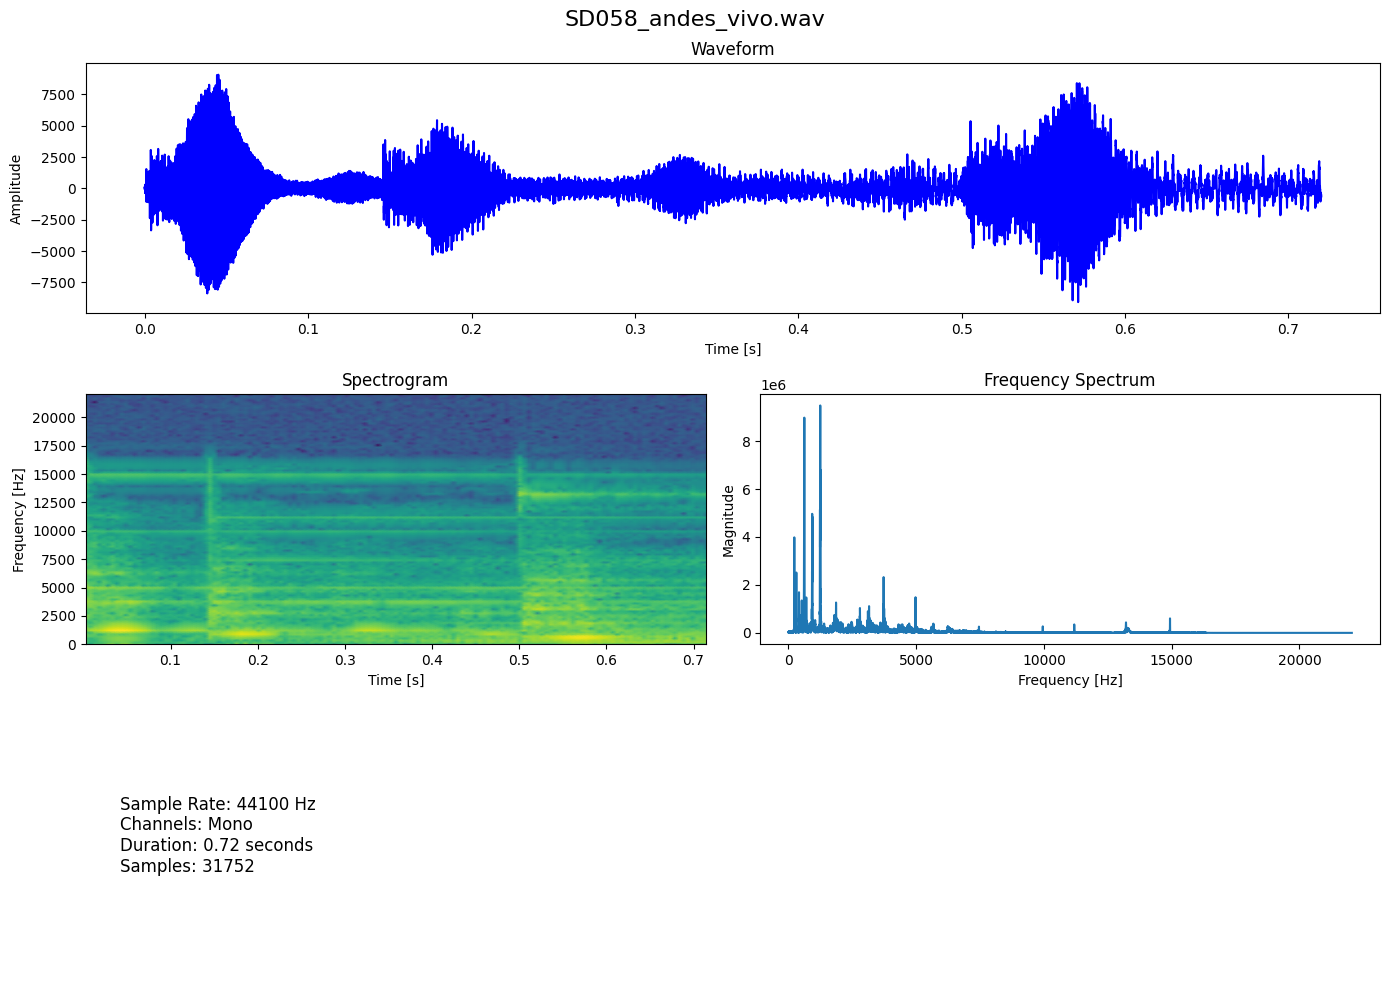

SD060_skyline_samsung.wav


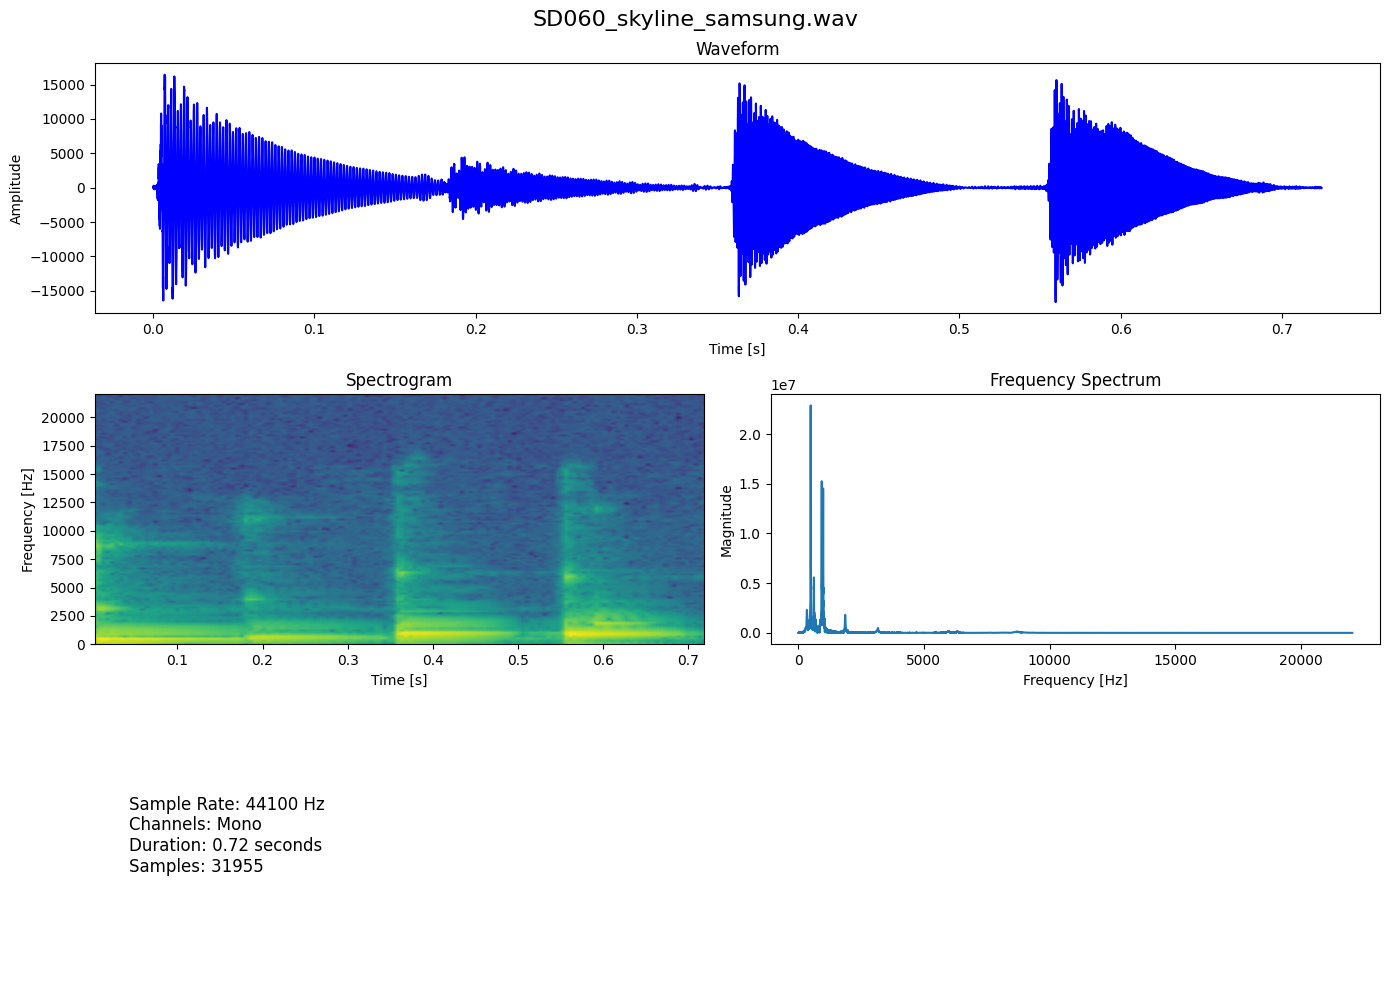

SD066_chime_moto.wav


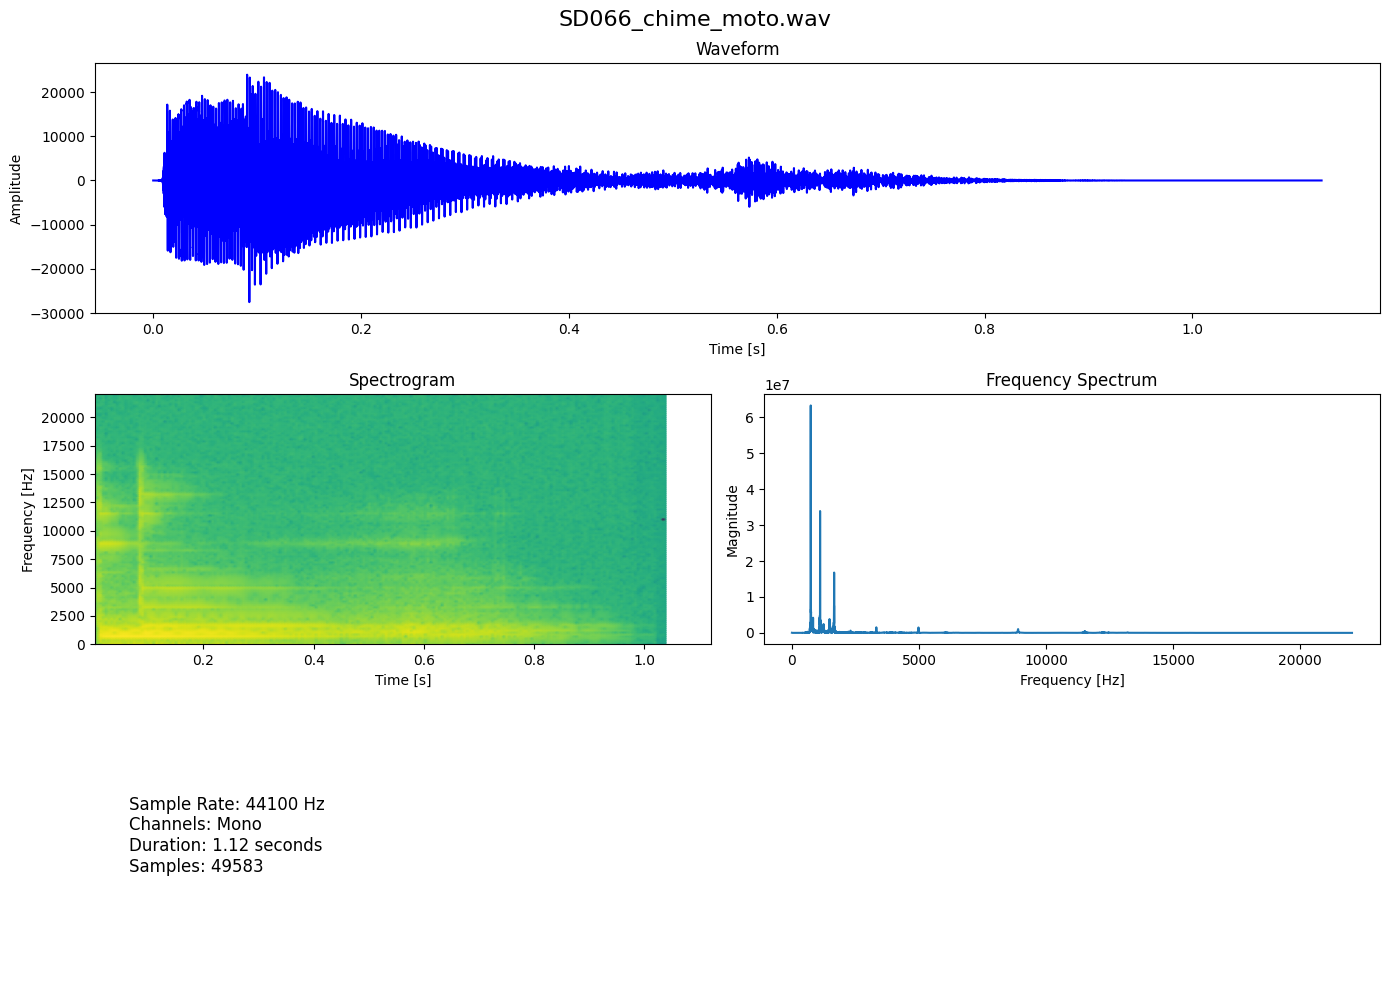

sub004_SD017_SD026_SD046_SD047_SD054__SD063_spaceline.wav


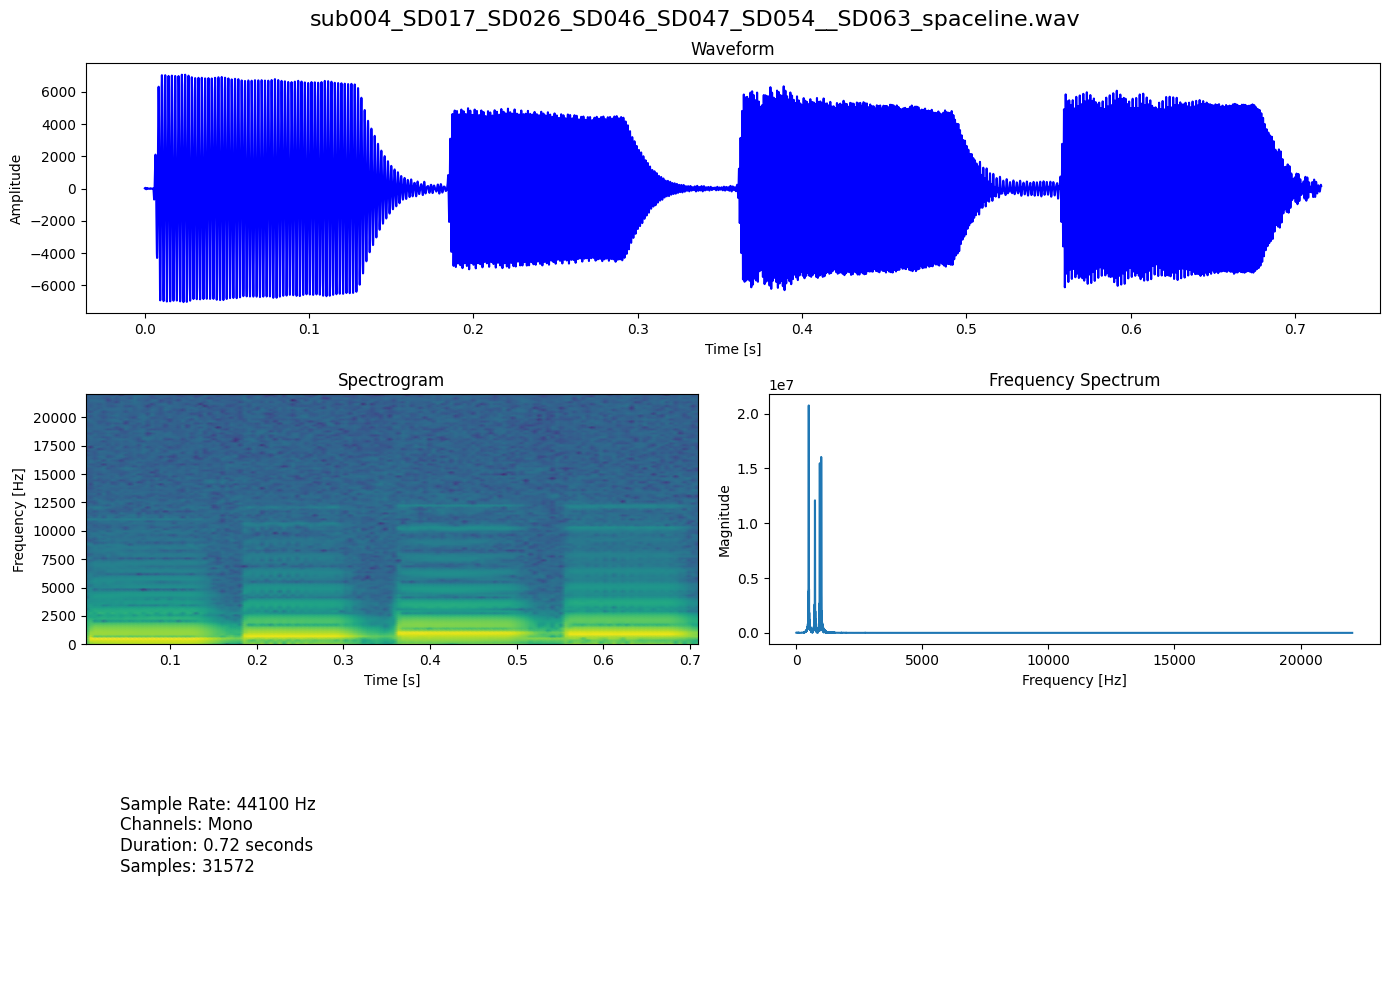

sub011_SD013_SD018_SD048_SD056_Sd061_SD064_Hello_inMoto.wav


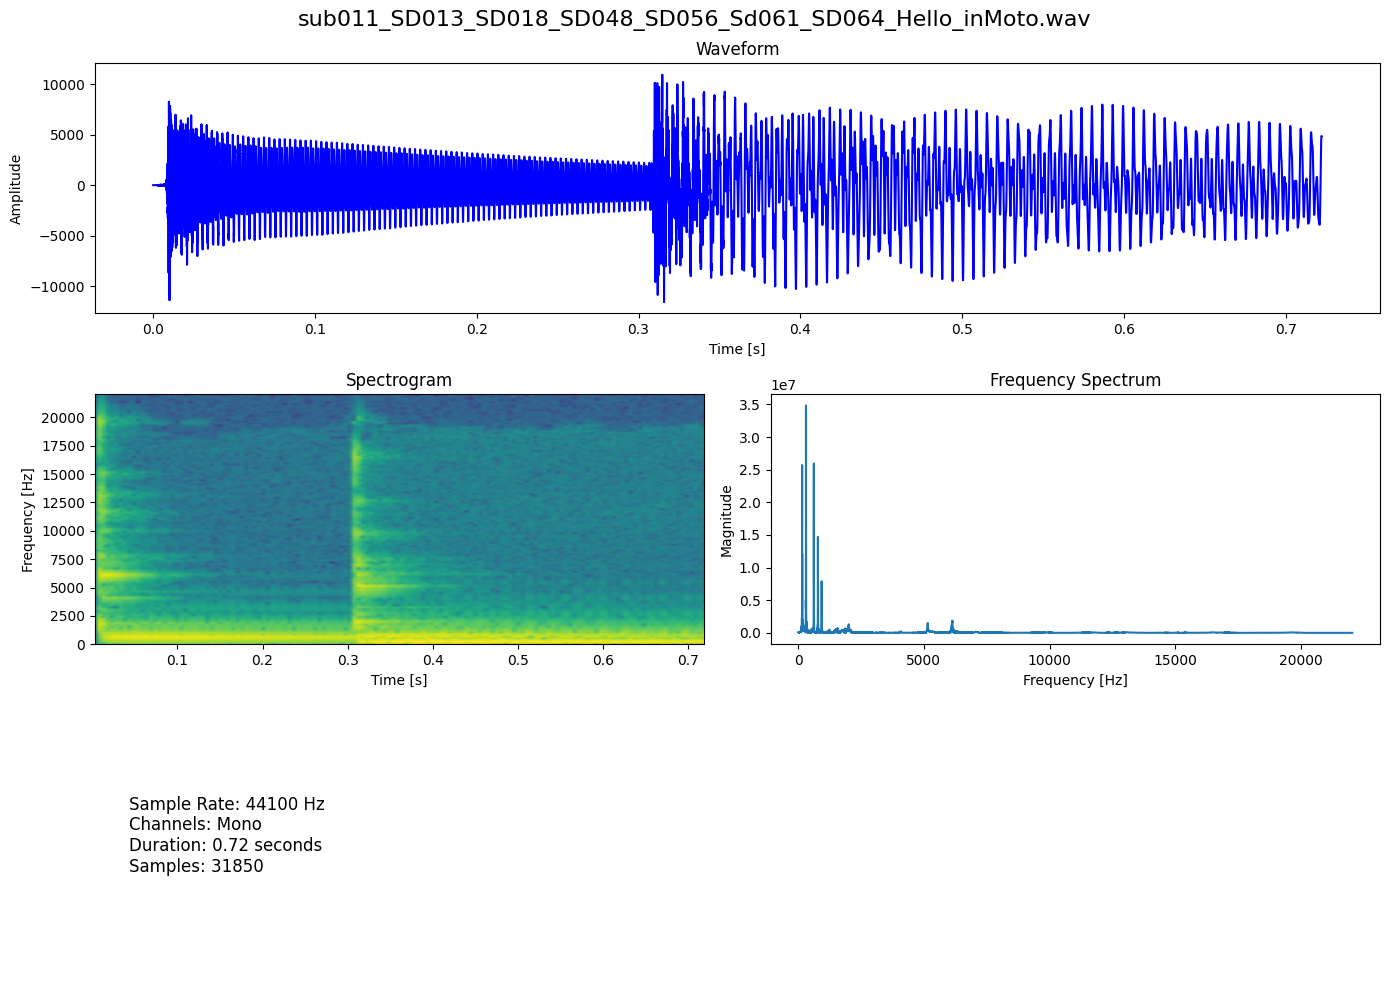

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import os 
audio_folder = r'E:\ecf-exp2-notif-mmn\data\Processed\audio'

 
for audio_ in os.listdir(audio_folder):
    # Load the .wav file
    print(audio_)
    try:
        rate, data = wav.read(os.path.join(audio_folder, audio_))
    except:
        print(audio_," NO able  to read")
        continue
    if data.ndim > 1:
        data = data[:, 0]  # use first channel if stereo
    duration = len(data) / rate
    time = np.linspace(0, duration, len(data))

    # FFT
    N = len(data)
    yf = fft(data)
    xf = fftfreq(N, 1 / rate)[:N//2]

    # Spectrogram
    f, t, Sxx = spectrogram(data, fs=rate)

    # Plot all in one figure
    plt.figure(figsize=(14, 10))
    plt.suptitle(audio_, fontsize=16)
    # 1. Waveform
    plt.subplot(3, 1, 1)
    plt.plot(time, data, color='blue')
    plt.title('Waveform')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')

    # 2. Spectrogram
    plt.subplot(3, 2, 3)
    plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    plt.title('Spectrogram')
    plt.xlabel('Time [s]')
    plt.ylabel('Frequency [Hz]')

    # 3. Frequency Spectrum
    plt.subplot(3, 2, 4)
    plt.plot(xf, np.abs(yf[:N//2]))
    plt.title('Frequency Spectrum')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude')

    # 4. Stats
    plt.subplot(3, 1, 3)
    plt.axis('off')
    stats = f"""
    Sample Rate: {rate} Hz
    Channels: {'Stereo' if data.ndim > 1 else 'Mono'}
    Duration: {duration:.2f} seconds
    Samples: {len(data)}
    """
    plt.text(0.01, 0.8, stats, fontsize=12, verticalalignment='top')

    plt.tight_layout()
    plt.show()
